# 🍓 Taller práctico: análisis estadístico de datos metagenómicos

## Pruebas de hipótesis con el microbioma de la fresa

**Clase práctica de 50 minutos · Python · Google Colab**

¿El microbioma de la raíz de una planta de fresa saludable es distinto del de una planta marchita?
Esa es la pregunta de una tesis de maestría en ciencias matemáticas, y hoy vamos a responderla
con los datos reales de esa tesis: 53 metagenomas de rizósfera de fresa, 35 de plantas saludables y
18 de plantas no saludables, clasificados con Kraken.

## Qué vas a aprender

| Minuto | Tema | Herramienta |
|---|---|---|
| 0–8 | Cargar y entender los datos | pandas |
| 8–14 | Qué es una prueba de hipótesis y qué significa el valor p | simulación con permutaciones |
| 14–22 | Comparar la diversidad de Shannon: prueba t y prueba de Welch | `scipy.stats` |
| 22–29 | Mann-Whitney y Wilcoxon: cuándo usar cada una | `scipy.stats` |
| 29–37 | Proporción de *Fusarium* en plantas saludables y no saludables | pandas + Mann-Whitney |
| 37–47 | Comparar la composición completa: PERMANOVA | Bray-Curtis a mano + permutaciones |
| 47–50 | Cierre: cómo reportar los resultados | tabla resumen |

Hay **siete ejercicios**. Cada uno tiene la solución escondida: intenta resolverlo antes de abrirla.

## Cómo usar este cuaderno

1. En Google Colab: **Archivo → Subir notebook**, o ábrelo desde GitHub con **Archivo → Abrir notebook → GitHub**.
2. Ejecuta las celdas en orden con **Mayús + Enter**. Los datos se descargan solos desde GitHub; no hay que subir nada.
3. Solo se usan `numpy`, `pandas`, `scipy` y `matplotlib`, que ya vienen instalados en Colab.

Los datos provienen del repositorio [CamilaSilva1995/Tesis_Maestria](https://github.com/CamilaSilva1995/Tesis_Maestria)
y fueron facilitados por la empresa Solena Ag.

## 1. Preparación

Importamos las librerías y definimos una función para cargar los datos. Si estás en Colab, los
archivos se leen directamente desde GitHub. Si tienes el repositorio en tu computadora, se leen de
la carpeta `datos/`.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import pdist, squareform

URL = "https://raw.githubusercontent.com/CamilaSilva1995/Tesis_Maestria/main/Taller_Practico/datos/"

def cargar(nombre):
    "Lee un CSV desde GitHub; si no hay internet, desde la carpeta local datos/."
    try:
        return pd.read_csv(URL + nombre)
    except Exception:
        return pd.read_csv("datos/" + nombre)

plt.rcParams.update({"figure.figsize": (8, 4.5), "font.size": 11})
COLORES = {"Saludable": "#F8766D", "No saludable": "#00BFC4"}   # los mismos colores de la tesis
print("Listo. numpy", np.__version__, "| pandas", pd.__version__, "| scipy", __import__("scipy").__version__)

Listo. numpy 1.26.4 | pandas 2.1.4 | scipy 1.11.4


## 2. Los datos

Tenemos tres tablas:

- **`metadatos.csv`**: una fila por muestra, con su grupo (`Saludable` o `No saludable`) y el número de lecturas que Kraken logró clasificar.
- **`diversidad_alfa.csv`**: para cada muestra, cuatro índices de diversidad alfa calculados con phyloseq sobre los 9 003 taxones de la tabla original: riqueza observada, Chao1, Shannon y Simpson.
- **`conteos_por_genero.csv`**: cuántas lecturas de cada muestra se asignaron a cada género. Hay 1 795 géneros (1 737 bacterianos y 58 eucariotas).

Cada muestra tiene un identificador como `MD2055` o `MP2099`. **Ese identificador es la llave que une las tres tablas.** Lo repetiremos varias veces en la clase: nunca se unen tablas "por posición", siempre por identificador.

In [2]:
meta  = cargar("metadatos.csv").set_index("muestra")
alfa  = cargar("diversidad_alfa.csv").set_index("muestra")
conteos = cargar("conteos_por_genero.csv")

print("Muestras en metadatos:", len(meta))
display(meta.head())
display(alfa.head())
display(conteos.iloc[:5, :8])   # primeras filas y columnas de la tabla de géneros

Muestras en metadatos: 58


,tratamiento,grupo,lecturas_clasificadas
muestra,,,
MD2055,wilted,No saludable,9782432
MD2056,wilted,No saludable,12468526
MD2065,wilted,No saludable,11297600
MD2066,wilted,No saludable,15580959
MD2075,wilted,No saludable,12310781


,observados,chao1,shannon,simpson
muestra,,,,
MD2055,8574,8720.286,7.466004,0.997774
MD2056,8654,8789.198,7.485615,0.997892
MD2065,8550,8744.387,7.318039,0.997244
MD2066,8706,8784.103,7.506399,0.997941
MD2075,8687,8811.039,7.437571,0.997770


,reino,filo,genero,MD2055,MD2056,MD2065,MD2066,MD2075
0,Bacteria,NaN,Candidatus Babela,28,41,19,49,47
1,Bacteria,NaN,Candidatus Chazhemtobacterium,38,58,28,61,58
2,Bacteria,Acidobacteria,Acidisarcina,1904,2351,1588,2932,1511
3,Bacteria,Acidobacteria,Acidobacterium,5478,6791,4553,8200,4130
4,Bacteria,Acidobacteria,Candidatus Koribacter,5478,6813,4506,8157,4177


### El filtro de calidad

La tesis descarta las muestras que, después del control de calidad con fastp, tenían **menos de 25 millones de lecturas**. Son cinco: `MP2079`, `MP2080`, `MP2088`, `MP2109` y `MP2137`. La más extrema, `MP2088`, conservó solo dos lecturas. Vamos a aplicar el mismo filtro y a unir las tablas por identificador.

In [3]:
excluir = ["MP2079", "MP2080", "MP2088", "MP2109", "MP2137"]

datos = meta.join(alfa, how="inner")          # une por el índice 'muestra'
datos = datos.drop(index=excluir)
muestras = list(datos.index)                  # las 53 muestras que usaremos en toda la clase

# dejamos la tabla de géneros con las mismas muestras y en el MISMO orden que 'datos'
generos = conteos.set_index(["reino", "filo", "genero"])[muestras]

print("Muestras tras el filtro:", len(datos))
print(datos.grupo.value_counts())
assert list(generos.columns) == muestras      # comprobación: mismo orden en las dos tablas

Muestras tras el filtro: 53
grupo
Saludable       35
No saludable    18
Name: count, dtype: int64


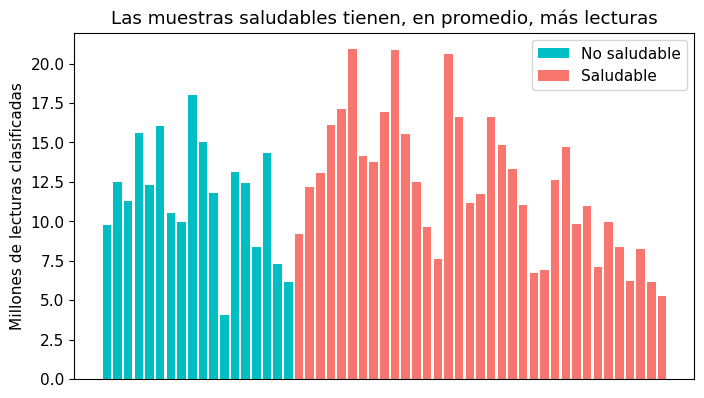

grupo
No saludable    11582705.0
Saludable       12241645.0
Name: lecturas_clasificadas, dtype: float64


In [4]:
# Lecturas clasificadas por muestra: ¿hay diferencia de profundidad entre grupos?
fig, ax = plt.subplots()
for g, sub in datos.groupby("grupo"):
    ax.bar(sub.index, sub.lecturas_clasificadas / 1e6, color=COLORES[g], label=g)
ax.set_ylabel("Millones de lecturas clasificadas"); ax.set_xticks([])
ax.set_title("Las muestras saludables tienen, en promedio, más lecturas"); ax.legend()
plt.show()
print(datos.groupby("grupo").lecturas_clasificadas.mean().round(0))

### ✏️ Ejercicio 1: Conocer los datos

Con las tablas ya cargadas, responde con código:

1. ¿Cuántos géneros de eucariotas hay en `generos`? ¿Y cuántos de bacterias?
2. ¿Cuál es el género con más lecturas en total? ¿De qué filo es?
3. ¿Por qué el filtro de calidad eliminó solo muestras saludables? Mira `meta.loc[excluir]`.

<details>
<summary><b>👉 Ver solución</b> (haz clic para desplegar)</summary>

1. Hay 58 géneros de eucariotas y 1 737 de bacterias. Los eucariotas están subrepresentados en la base de datos de Kraken, no necesariamente en el suelo.
2. *Streptomyces* (Actinobacteria), con diferencia. Es el género más abundante de la rizósfera de fresa en estos datos.
3. Las cinco muestras excluidas estaban etiquetadas como saludables. El filtro no "elige" grupo: simplemente esas cinco tuvieron pocas lecturas. Por eso el grupo saludable pasó de 40 a 35 muestras y el no saludable se quedó en 18.

```python
print(generos.reset_index().reino.value_counts())
total = generos.sum(axis=1).sort_values(ascending=False)
print(total.head(3))
print(meta.loc[excluir])
```

</details>

## 3. ¿Qué es una prueba de hipótesis? La idea con una simulación

Antes de usar ninguna fórmula, hagamos el razonamiento a mano con el índice de Shannon.

El promedio de Shannon es un poco mayor en las plantas saludables. La pregunta es: **¿esa diferencia es más grande de lo que se obtendría por puro azar?**

La **hipótesis nula** $H_0$ dice que el grupo no importa: la etiqueta "saludable" o "no saludable" es intercambiable. Si eso fuera cierto, podríamos **barajar las etiquetas** entre las 53 muestras y la diferencia de medias cambiaría solo por azar. Si barajamos 5 000 veces, obtenemos la distribución de la diferencia bajo $H_0$. El **valor p** es la fracción de barajadas que producen una diferencia tan grande, o más, que la observada.

Este razonamiento por permutaciones es exactamente el que usa el PERMANOVA al final de la clase.

Media saludable = 7.478   Media no saludable = 7.417   Diferencia = 0.061


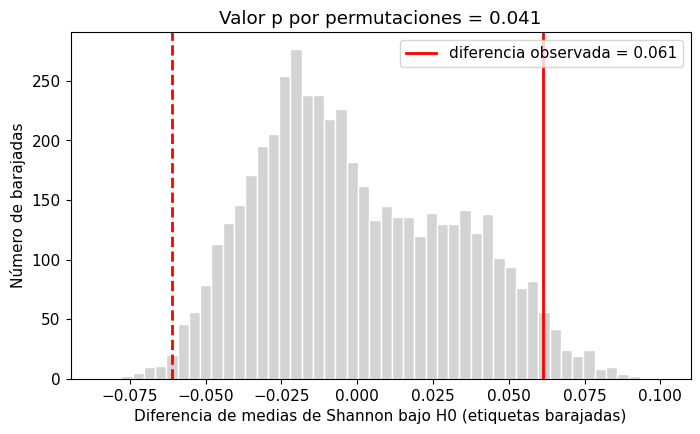

In [5]:
x = datos.loc[datos.grupo == "Saludable", "shannon"].to_numpy()
y = datos.loc[datos.grupo == "No saludable", "shannon"].to_numpy()
diferencia_obs = x.mean() - y.mean()
print(f"Media saludable = {x.mean():.3f}   Media no saludable = {y.mean():.3f}   Diferencia = {diferencia_obs:.3f}")

rng = np.random.default_rng(2026)
todos = np.concatenate([x, y])
dif_perm = []
for _ in range(5000):
    rng.shuffle(todos)                                   # barajar etiquetas
    dif_perm.append(todos[:len(x)].mean() - todos[len(x):].mean())
dif_perm = np.array(dif_perm)
p_perm = np.mean(np.abs(dif_perm) >= abs(diferencia_obs))   # bilateral

fig, ax = plt.subplots()
ax.hist(dif_perm, bins=50, color="lightgray", edgecolor="white")
ax.axvline(diferencia_obs, color="red", lw=2, label=f"diferencia observada = {diferencia_obs:.3f}")
ax.axvline(-diferencia_obs, color="red", lw=2, ls="--")
ax.set_xlabel("Diferencia de medias de Shannon bajo H0 (etiquetas barajadas)")
ax.set_ylabel("Número de barajadas"); ax.legend()
ax.set_title(f"Valor p por permutaciones = {p_perm:.3f}")
plt.show()

**Lee la figura.** La barra roja es lo que observamos. El histograma gris es lo que produce el azar cuando el grupo no importa. Solo un 4 % de las barajadas supera la diferencia observada: $p \approx 0.04$.

¿Entonces sí hay diferencia? **Guarda ese número.** En la siguiente sección veremos que otras pruebas sobre los mismos datos dan $p = 0.058$, $0.15$ y $0.26$, y entenderemos por qué: cada prueba hace supuestos distintos. El de esta simulación es que, bajo $H_0$, las etiquetas son intercambiables, es decir, que los dos grupos tienen la misma distribución, **varianza incluida**. Fíjate también en que el histograma es asimétrico: hay una planta no saludable con un Shannon muy bajo que arrastra la media del grupo en el que cae en cada barajada. Ese dato es una pista de que los dos grupos no se comportan igual.

Tres ideas que vale la pena fijar:

- Un valor p **no** es la probabilidad de que $H_0$ sea cierta. Es la probabilidad de ver un resultado así de extremo *si* $H_0$ fuera cierta.
- Un p mayor que 0.05 **no demuestra** que los grupos sean iguales. Solo dice que no tenemos evidencia suficiente para distinguirlos.
- El umbral $\alpha = 0.05$ se fija **antes** de mirar los datos.

### ✏️ Ejercicio 2: Interpretar el valor p

Sin escribir código, responde:

1. Si repitiéramos las 5 000 barajadas con otra semilla, ¿el valor p sería exactamente el mismo? ¿Por qué?
2. Un compañero dice: "p = 0.15 significa que hay 15 % de probabilidad de que los grupos sean iguales". ¿Qué está mal?
3. ¿Qué pasaría con el valor p si tuviéramos 500 muestras por grupo y la misma diferencia de medias?

<details>
<summary><b>👉 Ver solución</b> (haz clic para desplegar)</summary>

1. No exactamente. El valor p por permutaciones es una estimación de Monte Carlo: cambia un poco con la semilla. Con 5 000 barajadas la variación es de unas milésimas; con 99 barajadas sería mucho mayor. Por eso se reporta el número de permutaciones.
2. Confunde $P(\text{datos} \mid H_0)$ con $P(H_0 \mid \text{datos})$. El valor p se calcula suponiendo que $H_0$ es cierta; no dice nada sobre la probabilidad de $H_0$.
3. Con más muestras, la distribución bajo $H_0$ se vuelve más estrecha, porque el promedio de 500 valores barajados varía mucho menos que el de 35. La misma diferencia observada quedaría en la cola y el valor p bajaría. La significancia depende del tamaño de muestra tanto como del tamaño del efecto.

</details>

## 4. Diversidad alfa: la prueba t y la prueba de Welch

El índice de Shannon de una muestra es $H = -\sum_i p_i \ln p_i$, donde $p_i$ es la proporción de lecturas del taxón $i$. Resume en un número la riqueza (cuántos taxones) y la equidad (qué tan repartidas están las lecturas). Ya está calculado en la columna `shannon`; comprobemos la fórmula con una muestra usando la tabla de géneros.

In [6]:
def shannon(conteos):
    p = conteos / conteos.sum()
    p = p[p > 0]
    return -(p * np.log(p)).sum()

print("Shannon de MD2055 sobre la tabla de géneros:", round(shannon(generos["MD2055"]), 3))
print("Shannon de MD2055 sobre los 9 003 taxones (phyloseq):", datos.loc["MD2055", "shannon"].round(3))
print("Son distintos porque la tabla de géneros agrupa taxones; la tesis usa la tabla completa.")

Shannon de MD2055 sobre la tabla de géneros: 5.069
Shannon de MD2055 sobre los 9 003 taxones (phyloseq): 7.466
Son distintos porque la tabla de géneros agrupa taxones; la tesis usa la tabla completa.


La **prueba t** compara las medias de dos grupos. Su hipótesis nula es $H_0: \mu_{\text{sal}} = \mu_{\text{no sal}}$. Tiene dos versiones:

- **Varianzas iguales** (Student clásica): usa una varianza combinada y $n_1 + n_2 - 2$ grados de libertad.
- **Varianzas distintas** (Welch): usa cada varianza por separado y unos grados de libertad corregidos.

¿Cuál usar? Primero miramos si las varianzas son iguales con la **prueba F**, y si cada grupo es aproximadamente normal con **Shapiro-Wilk**. Esto es lo que hace la tesis.

In [7]:
print("Desviación estándar de Shannon:")
print(datos.groupby("grupo").shannon.std().round(3))

# Normalidad en cada grupo (Shapiro-Wilk): H0 = los datos son normales
for g, v in [("Saludable", x), ("No saludable", y)]:
    W, p = stats.shapiro(v)
    print(f"Shapiro-Wilk {g:13s}: W = {W:.3f}, p = {p:.4f}")

# Igualdad de varianzas (prueba F): H0 = sigma1^2 = sigma2^2
F = x.var(ddof=1) / y.var(ddof=1)
gl1, gl2 = len(x) - 1, len(y) - 1
p_F = 2 * min(stats.f.cdf(F, gl1, gl2), 1 - stats.f.cdf(F, gl1, gl2))
print(f"\nPrueba F: F = {F:.3f} con ({gl1}, {gl2}) gl, p = {p_F:.2e}")

Desviación estándar de Shannon:
grupo
No saludable    0.168
Saludable       0.061
Name: shannon, dtype: float64
Shapiro-Wilk Saludable    : W = 0.952, p = 0.1300
Shapiro-Wilk No saludable : W = 0.613, p = 0.0000

Prueba F: F = 0.132 con (34, 17) gl, p = 6.76e-07


Dos conclusiones: el grupo no saludable **no es normal** (hay una muestra con Shannon muy bajo) y las varianzas **son muy distintas** (la del grupo no saludable es unas siete veces mayor). Por lo tanto la versión correcta es la de Welch. Calculemos las dos para ver la diferencia.

t varianzas iguales: t = 1.939, gl = 51, p = 0.0581
t de Welch:          t = 1.499, gl = 19.3, p = 0.1501


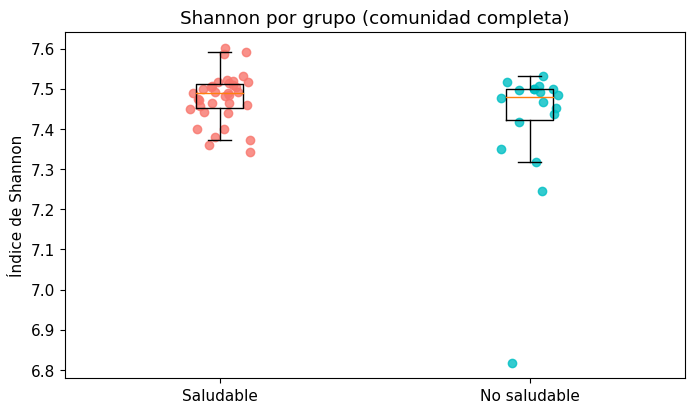

In [8]:
t_igual = stats.ttest_ind(x, y, equal_var=True)
t_welch = stats.ttest_ind(x, y, equal_var=False)

def gl_welch(x, y):
    vx, vy = x.var(ddof=1) / len(x), y.var(ddof=1) / len(y)
    return (vx + vy) ** 2 / (vx ** 2 / (len(x) - 1) + vy ** 2 / (len(y) - 1))

print(f"t varianzas iguales: t = {t_igual.statistic:.3f}, gl = {len(x)+len(y)-2}, p = {t_igual.pvalue:.4f}")
print(f"t de Welch:          t = {t_welch.statistic:.3f}, gl = {gl_welch(x, y):.1f}, p = {t_welch.pvalue:.4f}")

fig, ax = plt.subplots()
ax.boxplot([x, y], labels=["Saludable", "No saludable"], showfliers=False)
for i, (v, g) in enumerate([(x, "Saludable"), (y, "No saludable")], 1):
    ax.scatter(i + rng.uniform(-0.1, 0.1, len(v)), v, color=COLORES[g], alpha=0.8)
ax.set_ylabel("Índice de Shannon"); ax.set_title("Shannon por grupo (comunidad completa)")
plt.show()

Fíjate en algo importante: con varianzas iguales el valor p es 0.058, casi significativo; con Welch es 0.150. **Elegir mal el supuesto puede cambiar la conclusión.** Como los datos no cumplen el supuesto de varianzas iguales, el resultado que vale es el de Welch: no hay evidencia de que la diversidad promedio difiera.

¿Y el $p \approx 0.04$ de la simulación de la Sección 3? Barajar etiquetas supone que bajo $H_0$ los dos grupos tienen la misma distribución. Cuando el grupo pequeño es el más variable, como aquí, tanto esa simulación como la t con varianzas iguales se vuelven demasiado optimistas y dan valores p más pequeños de lo que deberían. **La respuesta correcta no es la de la prueba que da el p más pequeño, sino la de la prueba cuyos supuestos se cumplen.** Esto mismo volverá a aparecer con el PERMANOVA, que también se basa en barajar etiquetas.

Y la prueba F nos dio algo más interesante que la t: las plantas no saludables **son más variables entre sí**. Eso es un hallazgo en sí mismo.

### ✏️ Ejercicio 3: Repetir la comparación con otro índice

Repite el análisis de esta sección con el estimador de riqueza **Chao1** (columna `chao1`):

1. Calcula la media por grupo.
2. Aplica la prueba F y decide qué versión de la prueba t corresponde.
3. Aplica esa versión y escribe la conclusión en una frase.

<details>
<summary><b>👉 Ver solución</b> (haz clic para desplegar)</summary>

Las medias son muy parecidas: 8 768 frente a 8 752 especies estimadas. La prueba F da $p \approx 0.057$, justo por encima de 0.05, así que formalmente no se rechaza la igualdad de varianzas y corresponde la t clásica, que da $p \approx 0.35$. Un detalle instructivo: con un valor tan cercano al umbral, lo prudente es correr también Welch y comprobar que la conclusión no cambia (no cambia). Conclusión: no hay evidencia de que la riqueza estimada con Chao1 difiera entre plantas saludables y no saludables.

```python
xc = datos.loc[datos.grupo == "Saludable", "chao1"].to_numpy()
yc = datos.loc[datos.grupo == "No saludable", "chao1"].to_numpy()
print(datos.groupby("grupo").chao1.mean().round(1))
F = xc.var(ddof=1) / yc.var(ddof=1)
p_F = 2 * min(stats.f.cdf(F, len(xc)-1, len(yc)-1), 1 - stats.f.cdf(F, len(xc)-1, len(yc)-1))
print(f"F = {F:.3f}, p = {p_F:.4f}  ->", "varianzas distintas: Welch" if p_F < 0.05 else "varianzas iguales: t clásica")
r = stats.ttest_ind(xc, yc, equal_var=(p_F >= 0.05))
print(f"t = {r.statistic:.3f}, p = {r.pvalue:.4f}")
```

</details>

## 5. Mann-Whitney y Wilcoxon: cuándo usar cada una

Cuando los datos no son normales, como el grupo no saludable, se usan pruebas **basadas en rangos**: se ordenan todos los valores de menor a mayor y se trabaja con sus posiciones, no con los valores. Hay dos pruebas con el nombre de Wilcoxon y se confunden con frecuencia:

| Prueba | Nombres | Para qué sirve | Función en scipy |
|---|---|---|---|
| **Suma de rangos** | Wilcoxon rank-sum, Mann-Whitney U | Dos grupos **independientes** (nuestras plantas saludables y no saludables) | `stats.mannwhitneyu` |
| **Rangos con signo** | Wilcoxon signed-rank | Dos medidas **pareadas** sobre las mismas unidades (antes y después, o dos índices de la misma muestra) | `stats.wilcoxon` |

Para comparar los dos grupos de plantas la correcta es **Mann-Whitney**. Su estadístico $U$ cuenta cuántos pares (una muestra saludable, una no saludable) tienen el valor mayor en la saludable. Si los grupos fueran iguales, $U$ estaría cerca de la mitad de los pares posibles: $35 \times 18 / 2 = 315$.

Mann-Whitney sobre Shannon: U = 376 (de 630 pares), p = 0.2586
Nota: R reporta este mismo estadístico con el nombre W = 376.


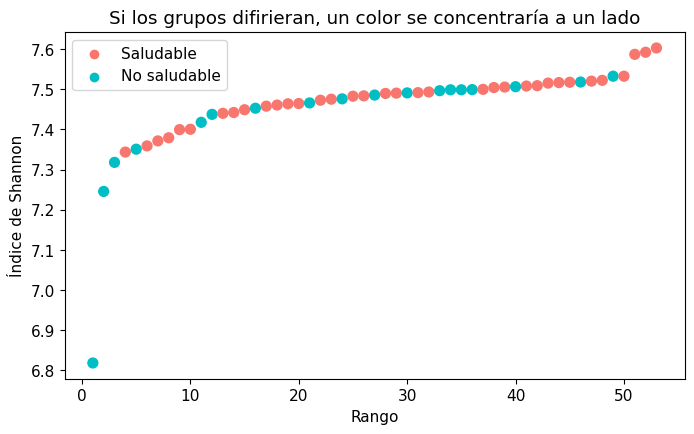

In [9]:
mw = stats.mannwhitneyu(x, y, alternative="two-sided", method="exact")   # "exact" es lo que usa R con n < 50
print(f"Mann-Whitney sobre Shannon: U = {mw.statistic:.0f} (de {len(x)*len(y)} pares), p = {mw.pvalue:.4f}")
print("Nota: R reporta este mismo estadístico con el nombre W = 376.")

# La figura de la tesis: los 53 valores ordenados por rango, coloreados por grupo
orden = datos.sort_values("shannon")
fig, ax = plt.subplots()
ax.scatter(range(1, 54), orden.shannon, c=orden.grupo.map(COLORES), s=50)
ax.set_xlabel("Rango"); ax.set_ylabel("Índice de Shannon")
ax.set_title("Si los grupos difirieran, un color se concentraría a un lado")
for g, c in COLORES.items():
    ax.scatter([], [], color=c, label=g)
ax.legend(); plt.show()

Los dos colores aparecen mezclados en todo el recorrido, y el valor p lo confirma. Mann-Whitney coincide con Welch.

### ¿Y la de rangos con signo?

Solo tiene sentido con **datos pareados**. Hagamos un ejemplo legítimo: para cada una de las 53 muestras tenemos dos medidas de la misma cosa, el Shannon calculado sobre toda la tabla de géneros y el Shannon calculado solo sobre los géneros bacterianos. ¿Difieren? Aquí cada muestra es su propio control, así que la prueba correcta es la de rangos con signo.

In [10]:
sh_todos    = generos.apply(shannon)                                          # Shannon por muestra, todos los géneros
sh_bacteria = generos.xs("Bacteria", level="reino").apply(shannon)            # solo géneros bacterianos
assert (sh_todos.index == sh_bacteria.index).all()                            # mismas muestras, mismo orden

w = stats.wilcoxon(sh_todos, sh_bacteria)
print(f"Diferencia mediana (todos - bacterias) = {np.median(sh_todos - sh_bacteria):.4f}")
print(f"Wilcoxon de rangos con signo: W = {w.statistic:.0f}, p = {w.pvalue:.2e}")
print("Aquí sí hay diferencia: quitar los eucariotas cambia el Shannon de cada muestra de forma sistemática.")

Diferencia mediana (todos - bacterias) = 0.0263
Wilcoxon de rangos con signo: W = 0, p = 2.39e-10
Aquí sí hay diferencia: quitar los eucariotas cambia el Shannon de cada muestra de forma sistemática.


### ✏️ Ejercicio 4: ¿Independientes o pareados?

Para cada situación, di qué prueba corresponde (Mann-Whitney o Wilcoxon de rangos con signo) y por qué:

1. Comparar la riqueza observada (`observados`) entre plantas saludables y no saludables.
2. Comparar, en las mismas 53 muestras, el índice de Simpson con el de Shannon.
3. Comparar el porcentaje de *Fusarium* en 10 plantas antes y después de aplicar un biocontrol.

Después, aplica la prueba del punto 1 con código.

<details>
<summary><b>👉 Ver solución</b> (haz clic para desplegar)</summary>

1. **Mann-Whitney**: son dos grupos de plantas distintas, independientes.
2. **Rangos con signo**: son dos medidas sobre las mismas muestras. Aunque en este caso la comparación tiene poco sentido biológico, porque los dos índices están en escalas diferentes.
3. **Rangos con signo**: cada planta se mide dos veces; el par es la planta.

Para el punto 1, el valor p es alto: la riqueza observada tampoco distingue a los grupos.

```python
xo = datos.loc[datos.grupo == "Saludable", "observados"]
yo = datos.loc[datos.grupo == "No saludable", "observados"]
r = stats.mannwhitneyu(xo, yo, alternative="two-sided", method="exact")
print(f"U = {r.statistic:.0f}, p = {r.pvalue:.4f}")
```

</details>

## 6. *Fusarium*: ¿hay más en las plantas marchitas?

*Fusarium* es un género de hongos que incluye a los causantes de la marchitez de la fresa. Si las plantas no saludables están enfermas por *Fusarium*, esperaríamos que tuvieran más lecturas de ese género. Vamos a calcular, para cada muestra, el **porcentaje de lecturas clasificadas que pertenecen a *Fusarium***.

Ojo con el denominador: dividimos entre **todas** las lecturas clasificadas de la muestra (columna `lecturas_clasificadas`), no solo entre las que tienen género. Y como los datos son **composicionales** (los porcentajes de una muestra suman 100), un aumento de *Fusarium* puede deberse a que otros taxones bajaron.

,mean,median,min,max
grupo,,,,
No saludable,0.151,0.127,0.065,0.387
Saludable,0.136,0.119,0.070,0.234


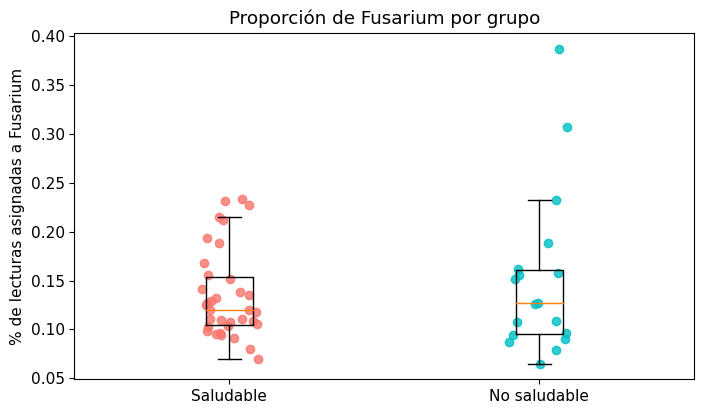

Mann-Whitney sobre % Fusarium: U = 317, p = 0.9777


In [11]:
fus = generos.xs("Fusarium", level="genero").iloc[0]            # lecturas de Fusarium por muestra
assert (fus.index == datos.index).all()                          # emparejadas por identificador
datos["fusarium_pct"] = 100 * fus / datos.lecturas_clasificadas

resumen = datos.groupby("grupo").fusarium_pct.agg(["mean", "median", "min", "max"]).round(3)
display(resumen)

fig, ax = plt.subplots()
xf = datos.loc[datos.grupo == "Saludable", "fusarium_pct"]
yf = datos.loc[datos.grupo == "No saludable", "fusarium_pct"]
ax.boxplot([xf, yf], labels=["Saludable", "No saludable"], showfliers=False)
for i, (v, g) in enumerate([(xf, "Saludable"), (yf, "No saludable")], 1):
    ax.scatter(i + rng.uniform(-0.1, 0.1, len(v)), v, color=COLORES[g], alpha=0.8)
ax.set_ylabel("% de lecturas asignadas a Fusarium"); ax.set_title("Proporción de Fusarium por grupo")
plt.show()

mwf = stats.mannwhitneyu(xf, yf, alternative="two-sided", method="exact")
print(f"Mann-Whitney sobre % Fusarium: U = {mwf.statistic:.0f}, p = {mwf.pvalue:.4f}")

*Fusarium* representa en promedio alrededor del 0.14 % de las lecturas en ambos grupos, con una superposición casi total y sin diferencia significativa. ¿Significa que *Fusarium* no tiene que ver con la enfermedad? No necesariamente:

- Kraken asigna lecturas al **género**; no distingue las cepas patógenas de las inocuas.
- Un porcentaje puede bajar aunque el número de células suba, si otros taxones subieron más.
- Con 18 plantas no saludables, la potencia para detectar diferencias pequeñas es baja.

**Una lección de la tesis.** Una versión anterior del análisis reportaba una diferencia muy significativa (p = 0.0017) en la diversidad de los géneros eucariotas, el grupo que contiene a *Fusarium*. Era un error: el script unía la tabla de diversidad con los metadatos **por posición**, y como una de las dos tablas estaba ordenada de otra manera, cada valor quedó asignado al grupo de otra muestra. Por eso en esta clase hay un `assert` cada vez que unimos tablas. Comprobar que los identificadores coinciden toma un segundo y evita un resultado falso con un valor p muy convincente.

### ✏️ Ejercicio 5: Otros géneros candidatos

Escribe una función `porcentaje(genero)` que devuelva el porcentaje de lecturas de ese género por muestra, y úsala para comparar entre grupos, con Mann-Whitney, estos tres géneros:

- *Phytophthora* (oomiceto patógeno de la fresa),
- *Ralstonia* (bacteria que causa marchitez),
- *Streptomyces* (bacteria benéfica, la más abundante).

¿Alguno difiere significativamente? Si hicieras esta prueba para los 1 795 géneros, ¿qué problema tendrías?

<details>
<summary><b>👉 Ver solución</b> (haz clic para desplegar)</summary>

*Ralstonia* y *Streptomyces* no difieren. *Phytophthora* sí sale significativo ($p \approx 0.013$), pero mira la dirección: es ligeramente **más** abundante en las plantas saludables (0.060 % frente a 0.055 %), lo contrario de lo que esperaríamos de un patógeno. Antes de celebrarlo, piensa en esto: acabamos de hacer tres pruebas, y en la clase llevamos ya más de diez. Si probáramos los 1 795 géneros, por puro azar unos 90 saldrían "significativos" con p < 0.05 aunque ningún género difiriera de verdad. Eso se llama el problema de las **comparaciones múltiples**, y se corrige ajustando los valores p, por ejemplo con el método de Benjamini-Hochberg (`statsmodels.stats.multitest.multipletests`). Con esa corrección, el resultado de *Phytophthora* no sobrevive. Un p aislado de 0.013 entre muchas pruebas es una hipótesis para un estudio nuevo, no un hallazgo.

```python
def porcentaje(genero):
    lecturas = generos.xs(genero, level="genero").sum(axis=0)   # sum: por si el género aparece en más de un filo
    return 100 * lecturas / datos.lecturas_clasificadas

for g in ["Phytophthora", "Ralstonia", "Streptomyces"]:
    v = porcentaje(g)
    a, b = v[datos.grupo == "Saludable"], v[datos.grupo == "No saludable"]
    r = stats.mannwhitneyu(a, b, alternative="two-sided", method="exact")
    print(f"{g:14s} media sal = {a.mean():.3f}%  media no sal = {b.mean():.3f}%  p = {r.pvalue:.3f}")
```

</details>

## 7. PERMANOVA: comparar la composición completa

Hasta ahora comparamos **un número por muestra**: Shannon, Chao1, el porcentaje de *Fusarium*. Pero una muestra es en realidad un vector de 1 795 abundancias. ¿Cómo comparamos vectores entre grupos?

**Paso 1: una distancia entre muestras.** Usamos la disimilitud de **Bray-Curtis**, calculada sobre abundancias relativas:

$$d_{BC}(x, y) = \frac{\sum_i |x_i - y_i|}{\sum_i (x_i + y_i)}$$

Vale 0 si dos muestras tienen la misma composición y 1 si no comparten ningún taxón.

**Paso 2: un estadístico.** El PERMANOVA (Anderson, 2001) reparte la variación total entre muestras en dos partes: la que hay **entre** grupos y la que hay **dentro** de los grupos, y forma un cociente llamado pseudo-F, igual que el ANOVA clásico. Si el grupo no importa, el pseudo-F es cercano a 1.

**Paso 3: el valor p por permutaciones.** Igual que en la Sección 3: barajamos las etiquetas de grupo muchas veces, recalculamos el pseudo-F y contamos cuántas veces supera al observado.

Vamos a programarlo a mano, en pocas líneas, para que no sea una caja negra.

In [12]:
# Paso 1: abundancias relativas y matriz de distancias (53 x 53)
rel = (generos / generos.sum(axis=0)).T          # filas = muestras, columnas = géneros, cada fila suma 1
assert np.allclose(rel.sum(axis=1), 1)
D = squareform(pdist(rel.to_numpy(), metric="braycurtis"))

# comprobación con la fórmula a mano para el primer par de muestras
a, b = rel.iloc[0].to_numpy(), rel.iloc[1].to_numpy()
print("Bray-Curtis a mano:", round(np.abs(a - b).sum() / (a + b).sum(), 4), "| scipy:", round(D[0, 1], 4))

Bray-Curtis a mano: 0.0406 | scipy: 0.0406


In [13]:
# Paso 2: pseudo-F a partir de la matriz de distancias
etiquetas = datos.grupo.to_numpy()

def pseudo_F(D, etiquetas):
    n = len(etiquetas)
    grupos = np.unique(etiquetas)
    SS_total = (D ** 2).sum() / (2 * n)
    SS_dentro = sum((D[np.ix_(etiquetas == g, etiquetas == g)] ** 2).sum() / (2 * (etiquetas == g).sum())
                    for g in grupos)
    SS_entre = SS_total - SS_dentro
    F = (SS_entre / (len(grupos) - 1)) / (SS_dentro / (n - len(grupos)))
    R2 = SS_entre / SS_total
    return F, R2

F_obs, R2 = pseudo_F(D, etiquetas)
print(f"pseudo-F observado = {F_obs:.3f}   R2 = {R2:.4f}  (el grupo explica el {100*R2:.1f} % de la variación)")

pseudo-F observado = 1.142   R2 = 0.0219  (el grupo explica el 2.2 % de la variación)


PERMANOVA (Bray-Curtis, 999 permutaciones): pseudo-F = 1.142, R2 = 0.0219, p = 0.282


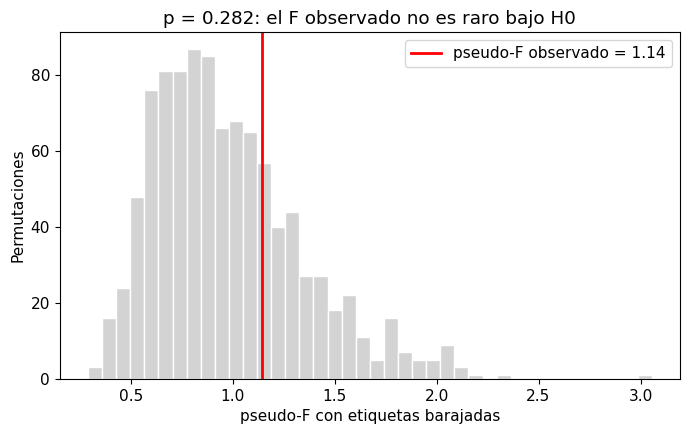

In [14]:
# Paso 3: valor p por permutaciones
def permanova(D, etiquetas, n_perm=999, semilla=2026):
    rng = np.random.default_rng(semilla)
    F_obs, R2 = pseudo_F(D, etiquetas)
    F_perm = np.array([pseudo_F(D, rng.permutation(etiquetas))[0] for _ in range(n_perm)])
    p = (np.sum(F_perm >= F_obs) + 1) / (n_perm + 1)        # +1: la observación cuenta como una permutación
    return F_obs, R2, p, F_perm

F_obs, R2, p, F_perm = permanova(D, etiquetas, n_perm=999)
print(f"PERMANOVA (Bray-Curtis, 999 permutaciones): pseudo-F = {F_obs:.3f}, R2 = {R2:.4f}, p = {p:.3f}")

fig, ax = plt.subplots()
ax.hist(F_perm, bins=40, color="lightgray", edgecolor="white")
ax.axvline(F_obs, color="red", lw=2, label=f"pseudo-F observado = {F_obs:.2f}")
ax.set_xlabel("pseudo-F con etiquetas barajadas"); ax.set_ylabel("Permutaciones"); ax.legend()
ax.set_title(f"p = {p:.3f}: el F observado no es raro bajo H0")
plt.show()

El estado de la planta explica alrededor del 2 % de la variación en la composición, y ese 2 % no se distingue de lo que produce el azar. En la tesis, calculado sobre los 9 003 taxones en lugar de los géneros, la conclusión es la misma: $R^2 = 0.024$, $p = 0.20$.

### Una advertencia que casi siempre se olvida: la dispersión

El PERMANOVA también reacciona cuando un grupo es **más disperso** que el otro, aunque sus centros coincidan. Con grupos desbalanceados (35 contra 18) esto importa. Por eso se acompaña con **PERMDISP**: se calcula la distancia de cada muestra al centro de su grupo y se comprueba si esas distancias difieren entre grupos. Si PERMDISP sale significativo, un PERMANOVA significativo podría deberse a la dispersión y no a la composición promedio.

In [15]:
def pcoa(D):
    "Coordenadas principales a partir de una matriz de distancias (para ubicar los centroides)."
    n = D.shape[0]
    A = -0.5 * D ** 2
    J = np.eye(n) - np.ones((n, n)) / n
    B = J @ A @ J
    val, vec = np.linalg.eigh(B)
    keep = val > 1e-10
    return vec[:, keep] * np.sqrt(val[keep])

def permdisp(D, etiquetas, n_perm=999, semilla=2026):
    coords = pcoa(D)
    dist_centro = np.empty(len(etiquetas))
    for g in np.unique(etiquetas):
        m = etiquetas == g
        centro = coords[m].mean(axis=0)
        dist_centro[m] = np.sqrt(((coords[m] - centro) ** 2).sum(axis=1))
    grupos = [dist_centro[etiquetas == g] for g in np.unique(etiquetas)]
    F_obs = stats.f_oneway(*grupos).statistic
    rng = np.random.default_rng(semilla)
    F_perm = [stats.f_oneway(*[dist_centro[rng.permutation(etiquetas) == g] for g in np.unique(etiquetas)]).statistic
              for _ in range(n_perm)]
    p = (np.sum(np.array(F_perm) >= F_obs) + 1) / (n_perm + 1)
    return dist_centro, F_obs, p

dist_centro, F_disp, p_disp = permdisp(D, etiquetas)
for g in np.unique(etiquetas):
    print(f"Distancia media al centroide, {g:13s}: {dist_centro[etiquetas == g].mean():.4f}")
print(f"PERMDISP: F = {F_disp:.3f}, p = {p_disp:.3f}")

Distancia media al centroide, No saludable : 0.0916
Distancia media al centroide, Saludable    : 0.0690
PERMDISP: F = 4.939, p = 0.005


Las plantas no saludables están, en promedio, más lejos de su centroide (0.092 frente a 0.069) y PERMDISP lo confirma con $p \approx 0.005$: **son más heterogéneas en composición**, igual que lo eran en Shannon. Este es el patrón que hay que reportar junto con el PERMANOVA: los grupos no difieren en su composición promedio, pero sí en cuánto varían. Es el resultado estadísticamente más sólido de todo el análisis.

### ✏️ Ejercicio 6: Cambiar la distancia y el nivel taxonómico

1. Repite el PERMANOVA usando la distancia de **Jaccard binaria** (presencia/ausencia): `pdist(rel.to_numpy() > 0, metric="jaccard")`. ¿Cambia la conclusión?
2. Repite el PERMANOVA usando **solo los géneros de eucariotas** (`generos.xs("Eukaryota", level="reino")`). ¿El estado de la planta explica más variación en esa fracción?
3. ¿Qué pasa con el valor p si usas 99 permutaciones en vez de 999? Córrelo tres veces con semillas distintas.

<details>
<summary><b>👉 Ver solución</b> (haz clic para desplegar)</summary>

1. Con Jaccard binaria el $R^2$ sube a cerca del 4 % y el valor p baja a 0.12, pero sigue sin ser significativo. La presencia o ausencia de géneros tampoco separa a los grupos.
2. En los eucariotas el $R^2$ es algo mayor (2.5 %), porque hay solo 58 géneros y cada uno pesa más, pero el valor p (0.22) sigue sin ser significativo.
3. Con 99 permutaciones el valor p solo puede tomar valores en múltiplos de 0.01 y varía bastante entre semillas. Con 999 la variación es de milésimas. Por eso lo habitual es usar al menos 999.

```python
# 1. Jaccard binaria
Dj = squareform(pdist(rel.to_numpy() > 0, metric="jaccard"))
print("Jaccard:", permanova(Dj, etiquetas)[:3])

# 2. Solo eucariotas
euk = generos.xs("Eukaryota", level="reino")
rel_e = (euk / euk.sum(axis=0)).T
De = squareform(pdist(rel_e.to_numpy(), metric="braycurtis"))
print("Eucariotas:", permanova(De, etiquetas)[:3])

# 3. Pocas permutaciones
for s in (1, 2, 3):
    print("99 permutaciones, semilla", s, "-> p =", round(permanova(D, etiquetas, n_perm=99, semilla=s)[2], 3))
```

</details>

## 8. Cierre: qué encontramos y cómo se reporta

Reunamos todas las pruebas en una tabla, que es la forma en que deben presentarse en un informe o una tesis: cada prueba con su estadístico, sus grados de libertad o permutaciones y su valor p.

In [16]:
resumen = pd.DataFrame([
    ["Shannon, comunidad completa", "t varianzas iguales", f"t = {t_igual.statistic:.3f}", f"{len(x)+len(y)-2}", t_igual.pvalue],
    ["Shannon, comunidad completa", "t de Welch",          f"t = {t_welch.statistic:.3f}", f"{gl_welch(x, y):.1f}", t_welch.pvalue],
    ["Shannon, comunidad completa", "Mann-Whitney",        f"U = {mw.statistic:.0f}", "-", mw.pvalue],
    ["Shannon, comunidad completa", "F de varianzas",      f"F = {F:.3f}", f"{gl1}, {gl2}", p_F],
    ["% Fusarium",                  "Mann-Whitney",        f"U = {mwf.statistic:.0f}", "-", mwf.pvalue],
    ["Composición (Bray-Curtis)",   "PERMANOVA",           f"F = {F_obs:.2f}, R2 = {R2:.3f}", "999 perm.", p],
    ["Composición (Bray-Curtis)",   "PERMDISP",            f"F = {F_disp:.2f}", "999 perm.", p_disp],
], columns=["Variable", "Prueba", "Estadístico", "gl / permutaciones", "p"])
resumen["p"] = resumen.p.map(lambda v: f"{v:.4f}" if v >= 1e-4 else f"{v:.1e}")
resumen["Rechaza H0 (α=0.05)"] = resumen.p.astype(float) < 0.05
display(resumen)

,Variable,Prueba,Estadístico,gl / permutaciones,p,Rechaza H0 (α=0.05)
0,"Shannon, comunidad completa",t varianzas iguales,t = 1.939,51,0.0581,False
1,"Shannon, comunidad completa",t de Welch,t = 1.499,19.3,0.1501,False
2,"Shannon, comunidad completa",Mann-Whitney,U = 376,-,0.2586,False
3,"Shannon, comunidad completa",F de varianzas,F = 0.132,"34, 17",6.8e-07,True
4,% Fusarium,Mann-Whitney,U = 317,-,0.9777,False
5,Composición (Bray-Curtis),PERMANOVA,"F = 1.14, R2 = 0.022",999 perm.,0.2820,False
6,Composición (Bray-Curtis),PERMDISP,F = 4.94,999 perm.,0.0050,True


**Qué aprendimos con los datos de la fresa:**

- La diversidad promedio es un poco mayor en las plantas saludables, pero la diferencia **no es significativa** con ninguna prueba. Con 35 y 18 muestras la potencia es baja; no significativo no quiere decir igual.
- Las plantas no saludables **son más variables entre sí**, tanto en diversidad (prueba F) como en composición (PERMDISP). Ese es el resultado más sólido.
- El estado de la planta explica solo un 2 % de la variación en la composición (PERMANOVA).
- La proporción de *Fusarium* es ligeramente mayor en las plantas no saludables, pero no de forma significativa.

**Qué aprendimos de estadística:**

- Elegir la prueba según el diseño (independientes o pareados) y los supuestos (normalidad, varianzas), **antes** de ver los valores p.
- Un valor p por permutaciones se construye barajando etiquetas; el PERMANOVA es ese mismo razonamiento con vectores.
- Reportar siempre el tamaño del efecto ($R^2$, diferencia de medias), el estadístico y el valor p, no solo "significativo" o "no significativo".
- Los mismos datos dieron $p = 0.04$, $0.058$, $0.15$ y $0.26$ según la prueba. La respuesta válida es la de la prueba cuyos supuestos se cumplen, no la que da el valor p más pequeño.
- Unir tablas por identificador, nunca por posición.

### ✏️ Ejercicio 7: Redactar el resultado

Escribe, en un párrafo de no más de cinco frases, el resultado de la comparación del índice de Shannon entre grupos, como lo pondrías en la sección de resultados de un artículo. Debe incluir: las medias, la prueba usada y por qué, el estadístico con sus grados de libertad, el valor p y la conclusión.

<details>
<summary><b>👉 Ver solución</b> (haz clic para desplegar)</summary>

Un párrafo modelo:

> El índice de Shannon promedio fue de 7.478 en las plantas saludables (n = 35) y de 7.417 en las no saludables (n = 18). Dado que la prueba F rechazó la igualdad de varianzas (F = 0.132, p < 0.001) y el grupo no saludable no cumplió el supuesto de normalidad (Shapiro-Wilk, p < 0.001), se aplicó la prueba t de Welch, que no detectó diferencia entre las medias (t = 1.50, gl = 19.3, p = 0.150), y la prueba de Mann-Whitney, que coincidió (U = 376, p = 0.259). Con el tamaño de muestra disponible no hay evidencia de que la diversidad de Shannon difiera entre grupos, aunque las plantas no saludables presentaron una variabilidad significativamente mayor.

Fíjate en que el párrafo justifica la elección de la prueba, da los números completos y no dice "los grupos son iguales".

</details>

## 9. Referencias

**Métodos estadísticos**

- Anderson, M. J. (2001). A new method for non-parametric multivariate analysis of variance. *Austral Ecology*, 26(1), 32–46. https://doi.org/10.1111/j.1442-9993.2001.01070.x
- Anderson, M. J. (2006). Distance-based tests for homogeneity of multivariate dispersions. *Biometrics*, 62(1), 245–253. https://doi.org/10.1111/j.1541-0420.2005.00440.x
- Benjamini, Y., & Hochberg, Y. (1995). Controlling the false discovery rate: a practical and powerful approach to multiple testing. *Journal of the Royal Statistical Society: Series B*, 57(1), 289–300. https://doi.org/10.1111/j.2517-6161.1995.tb02031.x
- Bray, J. R., & Curtis, J. T. (1957). An ordination of the upland forest communities of southern Wisconsin. *Ecological Monographs*, 27(4), 325–349. https://doi.org/10.2307/1942268
- Mann, H. B., & Whitney, D. R. (1947). On a test of whether one of two random variables is stochastically larger than the other. *The Annals of Mathematical Statistics*, 18(1), 50–60. https://doi.org/10.1214/aoms/1177730491
- Shannon, C. E. (1948). A mathematical theory of communication. *The Bell System Technical Journal*, 27(3), 379–423. https://doi.org/10.1002/j.1538-7305.1948.tb01338.x
- Shapiro, S. S., & Wilk, M. B. (1965). An analysis of variance test for normality (complete samples). *Biometrika*, 52(3-4), 591–611. https://doi.org/10.1093/biomet/52.3-4.591
- Welch, B. L. (1947). The generalization of "Student's" problem when several different population variances are involved. *Biometrika*, 34(1-2), 28–35. https://doi.org/10.1093/biomet/34.1-2.28
- Wilcoxon, F. (1945). Individual comparisons by ranking methods. *Biometrics Bulletin*, 1(6), 80–83. https://doi.org/10.2307/3001968
- Xia, Y., Sun, J., & Chen, D.-G. (2018). *Statistical Analysis of Microbiome Data with R*. Springer. https://doi.org/10.1007/978-981-13-1534-3

**Datos metagenómicos y composicionalidad**

- Gloor, G. B., Macklaim, J. M., Pawlowsky-Glahn, V., & Egozcue, J. J. (2017). Microbiome datasets are compositional: and this is not optional. *Frontiers in Microbiology*, 8, 2224. https://doi.org/10.3389/fmicb.2017.02224
- McMurdie, P. J., & Holmes, S. (2013). phyloseq: an R package for reproducible interactive analysis and graphics of microbiome census data. *PLoS ONE*, 8(4), e61217. https://doi.org/10.1371/journal.pone.0061217
- Wood, D. E., & Salzberg, S. L. (2014). Kraken: ultrafast metagenomic sequence classification using exact alignments. *Genome Biology*, 15, R46. https://doi.org/10.1186/gb-2014-15-3-r46

**Microbioma de la fresa**

- Siegieda, D., Panek, J., & Frąc, M. (2024). Ecological processes of bacterial microbiome assembly in healthy and dysbiotic strawberry farms. *BMC Plant Biology*, 24. https://doi.org/10.1186/s12870-024-05415-8
- Yang, J., Wei, S., Su, D., et al. (2020). Comparison of the rhizosphere soil microbial community structure and diversity between powdery mildew-infected and noninfected strawberry plants in a greenhouse by high-throughput sequencing technology. *Current Microbiology*, 77, 1724–1736. https://doi.org/10.1007/s00284-020-01948-x
- Zaneveld, J. R., McMinds, R., & Vega Thurber, R. (2017). Stress and stability: applying the Anna Karenina principle to animal microbiomes. *Nature Microbiology*, 2, 17121. https://doi.org/10.1038/nmicrobiol.2017.121

**Software**

- Harris, C. R., et al. (2020). Array programming with NumPy. *Nature*, 585, 357–362. https://doi.org/10.1038/s41586-020-2649-2
- Virtanen, P., et al. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272. https://doi.org/10.1038/s41592-019-0686-2
- Documentación de SciPy: [`ttest_ind`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html), [`mannwhitneyu`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html), [`wilcoxon`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.wilcoxon.html), [`shapiro`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html).

**Fuente de los datos y del análisis**

- Silva Gómez, P. C. (2026). *Análisis estadístico de la diversidad microbiana a distintos niveles taxonómicos en el microbioma rizosférico de plantas de fresa saludables y no saludables*. Tesis de Maestría en Ciencias Matemáticas, Posgrado Conjunto UMSNH-UNAM. Código y datos: https://github.com/CamilaSilva1995/Tesis_Maestria. Datos metagenómicos facilitados por Solena Ag.

---
*Material elaborado a partir de la tesis "Análisis estadístico de la diversidad microbiana a distintos niveles taxonómicos en el microbioma rizosférico de plantas de fresa saludables y no saludables" (Posgrado Conjunto en Ciencias Matemáticas UMSNH-UNAM). Datos facilitados por Solena Ag. Código y datos en [github.com/CamilaSilva1995/Tesis_Maestria/tree/main/Taller_Practico](https://github.com/CamilaSilva1995/Tesis_Maestria/tree/main/Taller_Practico).*